Copyright (C) 2026 Manuel Cotelo Ferreiro, Clara Jourdan (instituto de Fusión Nuclear Guillermo Velarde, Universidad POolitécnica de Madrid)

In [2]:
import numpy as np
import scipy as sp
import pandas as pd
from helpers import rwbeams, rwhist

import matplotlib.pyplot as plt

# Copyright (C) 2026 Clara Jourdan (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid) hereby claims all interest in program "beams"
# Copyright (C) 2026 Manuel Cotelo Ferreiro (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid) hereby claims all interest in program "hist"


# Load distribution from file

In [3]:
df_omega = rwbeams.read_beams("omega60_master_config.xlsx")

theta_edges, phi_edges, hs_reloaded = rwhist.read_histogram("omega60_illumination_map.csv")

In [4]:

# hs_reloaded is a 2D matrix (e.g., 50x50). We average it over axis 1 (the phi angle axis)
# to project it into a 1D vector 'fs' (50 values) depending purely on theta.
fs = np.mean(hs_reloaded, axis=1)


# Automatically dynamically adjust the number of bins for subsequent ray calculations
num = len(fs)

# Generate the bin edges for the theta polar angles from 0 to pi
theta_edges = np.linspace(0.0, np.pi, num + 1)

# helper variables 
theta_lo = theta_edges[:-1]
theta_hi = theta_edges[1:]

In [5]:
# validation
assert np.all( fs > 0.0 ), 'wrong intensities, must be positive'

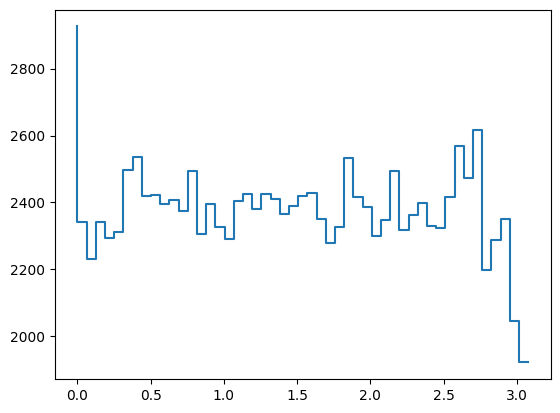

In [6]:
# plot initial distribution
fig, ax = plt.subplots()
ax.step( theta_edges[:-1],fs)

# Compute distribution of rays

In [7]:
# weight of each sector
ws = np.cos(theta_lo) - np.cos(theta_hi)
assert np.all( ws >= 0.0 ), 'wrong weights, must be positive'

# weighted function
es = fs * ws

In [8]:
num_rays = 10000

# energy per ray
e_per_ray = np.sum(es) / num_rays

# number of rays per sector
ns = np.array( [ int(np.ceil(ei/e_per_ray)) for ei in es ], )

In [9]:
# compute sectors
ts = [ theta_lo[0], ]

for i in range(num):
  # initialize list of angles for this subsector
  ti = [ theta_lo[i], ]
  # energy per ray in this sector
  ni = 2 * ns[i] + 1
  ei = es[i] / ni
  qi = ei / fs[i]
  for j in range(ni):
    ti.append(np.arccos(np.cos(ti[-1]) - (qi)))
  ti[-1] = theta_hi[i]
  ti = ti[1::2]

  ts += ti

ts = np.array(ts)

assert np.all( np.diff(ts) >= 0.0 ), 'angles are not sorted'

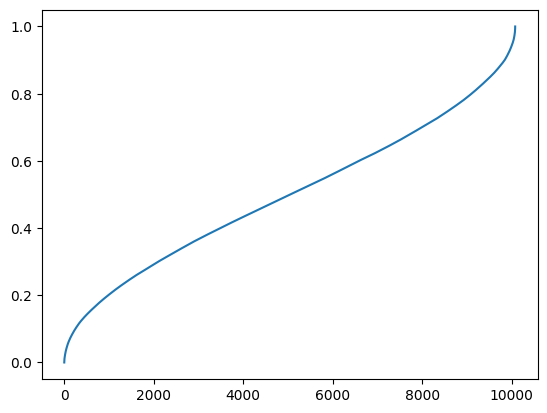

In [10]:
fig, ax = plt.subplots()
ax.plot(ts/np.pi)

# Create ray coordinates

In [11]:
R = 1.

xs = R * np.stack( [ np.sin(ts), np.cos(ts), ])
us = -xs
us = us / np.linalg.norm(us, axis=0)

print(xs.shape)
print(us.shape)

(2, 10078)
(2, 10078)


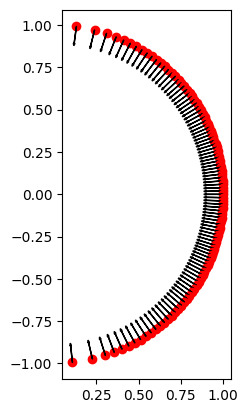

In [12]:
fig, ax = plt.subplots()

ax.set_aspect('equal')

num_rays_plot = 100
inc = xs.shape[1] // num_rays_plot
begin = inc // 2

x, y = xs[0,begin::inc], xs[1,begin::inc]
u, v = us[0,begin::inc], us[1,begin::inc]

f = 0.10

for xi, yi, ui, vi in zip(x,y,u,v):
  dx = f*ui
  dy = f*vi
  ax.scatter(xi,yi,color='r')
  ax.arrow(xi,yi,dx,dy,head_width=0.01)

In [13]:
# filter out points with negative "z" coordinate
mask = xs[1] >= 0.0

xf = xs[:,mask]
uf = us[:,mask]

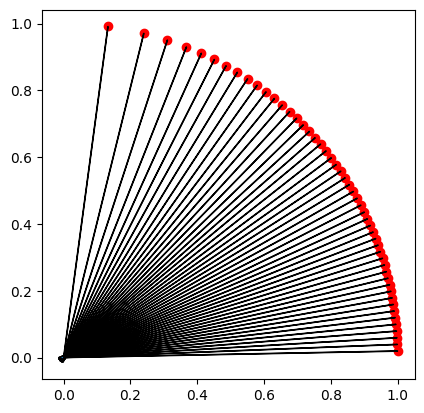

In [14]:
fig, ax = plt.subplots()

ax.set_aspect('equal')

num_rays_plot = 100
inc = xs.shape[1] // num_rays_plot
begin = inc // 2

x, y = xf[0,begin::inc], xf[1,begin::inc]
u, v = uf[0,begin::inc], uf[1,begin::inc]

f = 1.00

for xi, yi, ui, vi in zip(x,y,u,v):
  dx = f*ui
  dy = f*vi
  ax.scatter(xi,yi,color='r')
  ax.arrow(xi,yi,dx,dy,head_width=0.01)

## Angle calculation

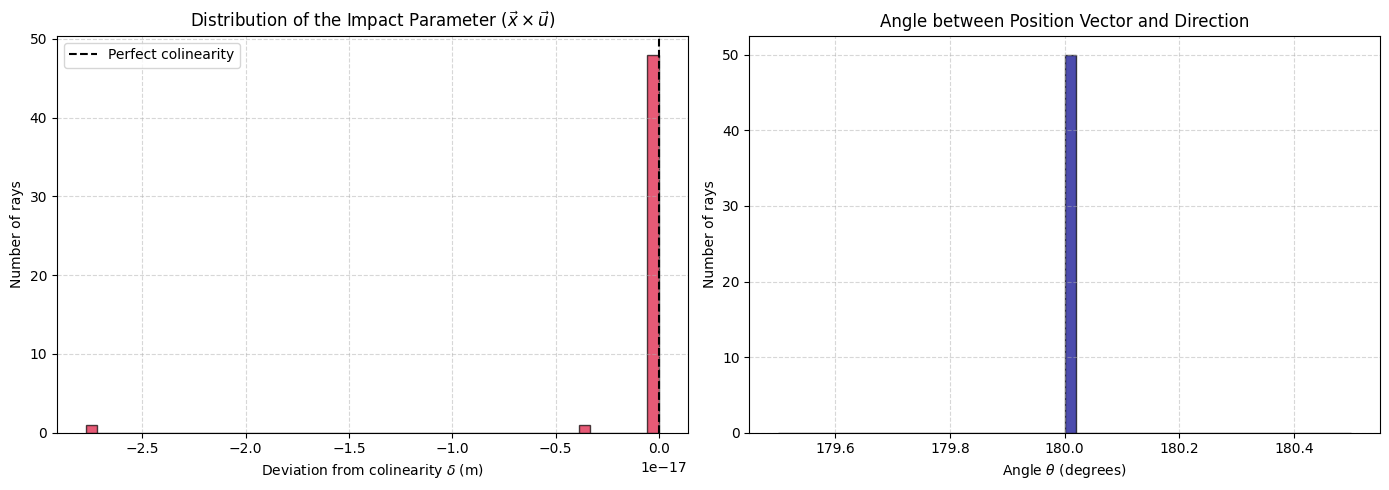

--- GEOMETRIC ASSESSMENT ---
Maximum deviation from center (delta_max): 2.7756e-17 m
Mean angle between position and direction: 180.00°


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = np.loadtxt('rays_init_method_A.txt')
x, y, u, v = data[:, 0], data[:, 1], data[:, 2], data[:, 3]

# Compute angle between position and direction vectors
norm_pos = np.sqrt(x**2 + y**2)
norm_dir = np.sqrt(u**2 + v**2)

with np.errstate(divide='ignore', invalid='ignore'):
    cos_theta = (x * u + y * v) / (norm_pos * norm_dir)
    cos_theta = np.nan_to_num(cos_theta, nan=-1.0)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

angles_deg = np.degrees(np.arccos(cos_theta))

# Calculate deviation from 180 degrees
angle_errors = angles_deg - 180.0

# Simple plot of the error distribution
plt.figure(figsize=(8, 5))
plt.hist(angle_errors, bins=50, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Perfect alignment')

plt.xlabel('Error from 180° (degrees)')
plt.ylabel('Ray count')
plt.title('Angular Distribution Error')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.tight_layout()
plt.show()

# Print metrics
print(f"Mean absolute error: {np.mean(np.abs(angle_errors)):.2e}°")
print(f"Max absolute error: {np.max(np.abs(angle_errors)):.2e}°")

# Write data to file

In [16]:
file_name = 'rays_init_method_A.txt'
with open(file_name,'w') as fd:
  print('\n'.join([ f'{xi:15.7e} {yi:15.7e} {ui:15.7e} {vi:15.7e}' for xi, yi, ui, vi in zip(xf[0],xf[1],uf[0],uf[1]) ]), file=fd, )